# 09 — Permutation / Shuffle Test

Addresses selection-bias criticism directly:
- For each crop, shuffle altitude labels randomly among RSUs
- Re-run regression 5000 times
- Compare observed r² to null distribution
- Report empirical p-value: proportion of shuffles ≥ observed r²

If the observed relationship is real, it should lie far in the tail of the null.
If it reflects structured sampling, shuffles will often match it.

Saves `../writing/fig_permutation.png`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import linregress

WRITING = '../writing'
N_PERM = 5000
RNG = np.random.default_rng(42)

from rsu_loader import load_all_rsus
rsus = load_all_rsus()

# Build RSU-level env DataFrame (altitude, temperature) — not in matrix CSV
env_rows = []
for r in rsus:
    env_rows.append({
        'region_id': r.region_id,
        'altitude_m': getattr(r.coordinates, 'altitude_m', None),
        'temp_mean':  r.climate.temperature_mean,
    })
env_df = pd.DataFrame(env_rows).set_index('region_id')

import os
matrix_path = '../data/metabolites/rsu_metabolite_matrix.csv'
if os.path.exists(matrix_path):
    food_df_raw = pd.read_csv(matrix_path, index_col=[0, 1])
    food_df = food_df_raw.join(env_df, on='region_id')
    print(f'Loaded matrix: {food_df.shape}')
else:
    raise FileNotFoundError(matrix_path)

Loaded matrix: (268, 35)


In [2]:
# ── Collect (altitude, y) pairs for each crop ─────────────────────────────────
CGA_COL  = 'key_flavor_bioactives.polyphenol_content'
CLA_COL  = 'key_flavor_bioactives.conjugated_linoleic_acid'
MALIC    = 'organic_acids.malic_acid'
CAT_COL  = 'key_flavor_bioactives.polyphenol_content'

coffee_ids = {'RSU-47', 'RSU-48', 'RSU-18', 'RSU-27', 'RSU-54', 'RSU-17'}
butter_ids = {'RSU-46', 'RSU-37', 'RSU-51', 'RSU-52', 'RSU-53', 'RSU-36', 'RSU-42'}
apple_ids  = {'RSU-13', 'RSU-49', 'RSU-55', 'RSU-14', 'RSU-50'}
TEA_INCLUDE = {'RSU-20', 'RSU-27', 'RSU-56', 'RSU-58', 'RSU-61', 'RSU-62', 'RSU-63', 'RSU-64', 'RSU-65'}
TEA_EXCLUDE = {'RSU-22', 'RSU-26', 'RSU-57', 'RSU-60'}

def get_xy_multiindex(df, rsu_ids, ycol, log_x=False):
    sub = df[df.index.get_level_values('region_id').isin(rsu_ids)]
    if ycol not in sub.columns:
        return np.array([]), np.array([])
    x = pd.to_numeric(sub['altitude_m'], errors='coerce').values
    y = pd.to_numeric(sub[ycol], errors='coerce').values
    mask = ~(np.isnan(x) | np.isnan(y)) & (x > 0)
    x, y = x[mask], y[mask]
    return np.log(x) if log_x else x, y

def get_xy_simple(df, ycol, log_x=False):
    if ycol not in df.columns:
        return np.array([]), np.array([])
    x = pd.to_numeric(df['altitude_m'], errors='coerce').values
    y = pd.to_numeric(df[ycol], errors='coerce').values
    mask = ~(np.isnan(x) | np.isnan(y)) & (x > 0)
    x, y = x[mask], y[mask]
    return np.log(x) if log_x else x, y

coffee_mask = food_df.index.get_level_values('food_name').str.lower().str.contains('coffee|arabica')
coffee_df = food_df[coffee_mask]
# Butter: exclude "butter tea (po cha)" — RSU-42 has two butter-matching foods
butter_mask = (food_df.index.get_level_values('food_name').str.lower().str.contains('butter') &
               ~food_df.index.get_level_values('food_name').str.lower().str.contains('tea|po cha'))
butter_df = food_df[butter_mask]
apple_mask = food_df.index.get_level_values('food_name').str.lower().str.contains('golden delicious')
apple_df = food_df[apple_mask]

tea_rows = []
for rid in TEA_INCLUDE - TEA_EXCLUDE:
    sub = food_df[food_df.index.get_level_values('region_id') == rid]
    if CAT_COL not in sub.columns:
        continue
    for _, row in sub.iterrows():
        val = pd.to_numeric(row[CAT_COL], errors='coerce')
        if pd.notna(val) and 5 < val < 30:
            tea_rows.append(row.rename(rid))
            break
tea_df = pd.DataFrame(tea_rows)
tea_df.index.name = 'region_id'

# (df, ids, ycol, color, mode, log_x)
# Butter uses log(altitude) — pre-specified model
datasets = [
    ('Coffee CGA',   coffee_df, coffee_ids, CGA_COL,  '#2166ac', 'multi',  False),
    ('Coffee malic', coffee_df, coffee_ids, MALIC,    '#5aace4', 'multi',  False),
    ('Butter CLA',   butter_df, butter_ids, CLA_COL,  '#4dac26', 'multi',  True),
    ('Apple malic',  apple_df,  apple_ids,  MALIC,    '#c94040', 'multi',  False),
]
if len(tea_df) >= 4:
    datasets.append(('Tea catechins', tea_df, None, CAT_COL, '#d95f02', 'simple', False))

for label, df, ids, ycol, color, mode, log_x in datasets:
    x, y = (get_xy_simple(df, ycol, log_x) if mode == 'simple'
            else get_xy_multiindex(df, ids, ycol, log_x))
    print(f'{label}: n={len(x)}')

Coffee CGA: n=6
Coffee malic: n=5
Butter CLA: n=7
Apple malic: n=5
Tea catechins: n=9


In [3]:
# ── Permutation test ──────────────────────────────────────────────────────────
# For butter: shuffle log(altitude) labels — consistent with pre-specified log model.
def r2_obs(x, y):
    if len(x) < 3:
        return None
    _, _, r, _, _ = linregress(x, y)
    return r**2

def permutation_r2(x, y, n_perm=N_PERM, rng=RNG):
    null = np.empty(n_perm)
    for i in range(n_perm):
        x_shuf = rng.permutation(x)
        _, _, r, _, _ = linregress(x_shuf, y)
        null[i] = r**2
    return null

perm_results = []
for label, df, ids, ycol, color, mode, log_x in datasets:
    x, y = (get_xy_simple(df, ycol, log_x) if mode == 'simple'
            else get_xy_multiindex(df, ids, ycol, log_x))
    if len(x) < 3:
        continue
    obs = r2_obs(x, y)
    null = permutation_r2(x, y)
    emp_p = (null >= obs).mean()
    xlabel = 'log(altitude)' if log_x else 'altitude'
    perm_results.append({
        'label': label,
        'color': color,
        'n': len(x),
        'obs_r2': obs,
        'null': null,
        'emp_p': emp_p,
        'pct_rank': 100 * (1 - emp_p),
        'xlabel': xlabel,
    })
    print(f'{label}: obs r²={obs:.3f}, empirical p={emp_p:.4f} ({100*(1-emp_p):.1f}th pct) [{xlabel}]')

Coffee CGA: obs r²=0.874, empirical p=0.0088 (99.1th pct) [altitude]
Coffee malic: obs r²=0.921, empirical p=0.0232 (97.7th pct) [altitude]
Butter CLA: obs r²=0.923, empirical p=0.0008 (99.9th pct) [log(altitude)]
Apple malic: obs r²=0.912, empirical p=0.0076 (99.2th pct) [altitude]
Tea catechins: obs r²=0.490, empirical p=0.0310 (96.9th pct) [altitude]


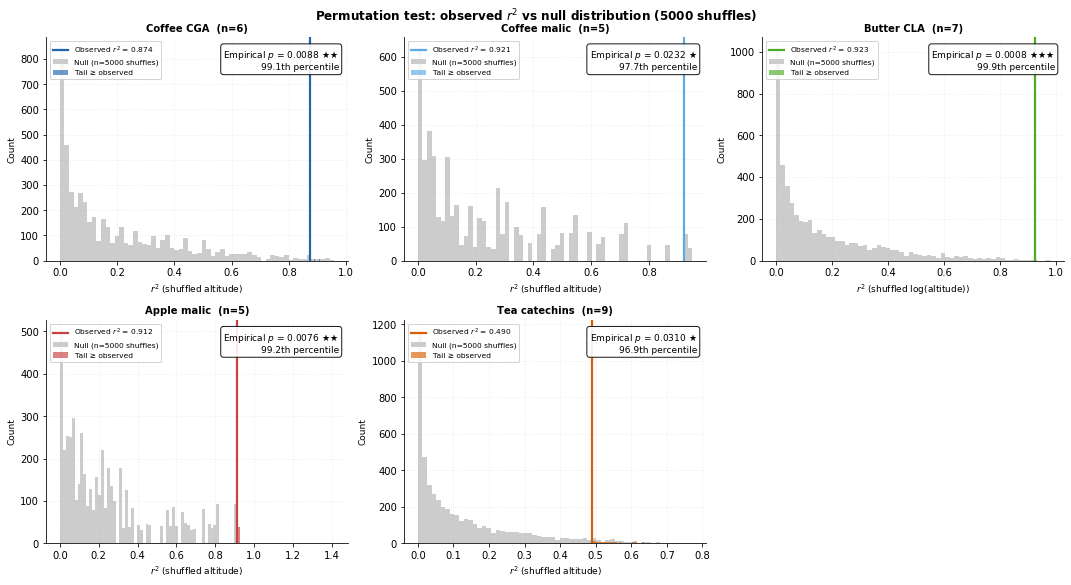

Saved → ../writing/fig_permutation.png


In [4]:
# ── Figure ────────────────────────────────────────────────────────────────────
RCPARAMS = {'font.family': 'sans-serif', 'axes.spines.top': False,
            'axes.spines.right': False, 'axes.grid': True,
            'grid.alpha': 0.30, 'grid.linestyle': ':'}

ncols = min(len(perm_results), 3)
nrows = (len(perm_results) + ncols - 1) // ncols

with plt.rc_context(RCPARAMS):
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.array(axes).flatten()

    for idx, res in enumerate(perm_results):
        ax = axes_flat[idx]
        null = res['null']
        obs  = res['obs_r2']
        color = res['color']
        xlabel = res.get('xlabel', 'altitude')

        ax.hist(null, bins=60, color='#cccccc', edgecolor='none',
                label=f'Null (n={N_PERM} shuffles)')
        tail = null[null >= obs]
        if len(tail) > 0:
            ax.hist(tail, bins=60, color=color, alpha=0.65, edgecolor='none',
                    label='Tail ≥ observed')
        ax.axvline(obs, color=color, lw=2.2, label=f'Observed $r^2$ = {obs:.3f}')

        emp_p = res['emp_p']
        stars = '★★★' if emp_p < 0.001 else ('★★' if emp_p < 0.01 else ('★' if emp_p < 0.05 else 'ns'))
        ax.text(0.97, 0.95,
                f'Empirical $p$ = {emp_p:.4f} {stars}\n{res["pct_rank"]:.1f}th percentile',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.9))

        ax.set_xlabel(f'$r^2$ (shuffled {xlabel})', fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.set_title(f'{res["label"]}  (n={res["n"]})', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7.5, framealpha=0.85, loc='upper left')

    for idx in range(len(perm_results), len(axes_flat)):
        axes_flat[idx].set_visible(False)

    fig.suptitle(
        f'Permutation test: observed $r^2$ vs null distribution ({N_PERM} shuffles)',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    path = f'{WRITING}/fig_permutation.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')

In [5]:
# ── Summary for paper text ────────────────────────────────────────────────────
print('\n=== PERMUTATION TEST SUMMARY ===')
print(f'{"Crop":<20} {"n":>3}  {"Obs r²":>8}  {"Emp p":>8}  {"Rank":>8}')
for res in perm_results:
    print(f"{res['label']:<20} {res['n']:>3}  {res['obs_r2']:>8.3f}  {res['emp_p']:>8.4f}  {res['pct_rank']:>7.1f}th")


=== PERMUTATION TEST SUMMARY ===
Crop                   n    Obs r²     Emp p      Rank
Coffee CGA             6     0.874    0.0088     99.1th
Coffee malic           5     0.921    0.0232     97.7th
Butter CLA             7     0.923    0.0008     99.9th
Apple malic            5     0.912    0.0076     99.2th
Tea catechins          9     0.490    0.0310     96.9th
